# RQ1: do attribution methods agree?

Good attribution methods should agree on what is important: if two methods
disagree, at least one of them is underperforming (agreement alone does not prove
they are right, but disagreement is a red flag). This is the agreement paradigm
from `literature/agree.pdf`. We test it on our two attribution analyses, and the
two turn out to behave very differently.

- **sparse_to_logits**: input is the sparse code, target is the predicted class
  logit. We compare how the methods rank the sparse dimensions.
- **image_to_sparse**: input is the image pixels, target is a sparse dimension. We
  compare how the methods rank the pixels.

We compare every pair of methods with four overlap measures (in `agree.py`):
Kendall's tau, Overlap@k, Jaccard@k and rank biased overlap. The notebook is laid
out as: shared setup, then a demo for each analysis side by side, then the final
agreement matrices for each analysis side by side.

In [9]:
import json
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt

import agree

OUTPUT = Path("output")
RUNS = {
    "efficientnet": "efficientnet_adamw_l10.0004_lr0.001_x32_e200_b4096_n100000_seed0",
    "mobilenet": "mobilenet_adamw_l10.0004_lr0.001_x32_e200_b4096_n100000_seed0",
}

# parameters of the overlap measures
DIM_TOP_K = 25     # cutoff for the sparse_to_logits dimensions (~40k, mostly tiny)
PIXEL_TOP_K = 500  # cutoff for the image_to_sparse pixels (~50k per image)
RBO_P = 0.9        # rank biased overlap weight (higher looks deeper down the ranking)
RBO_DEPTH = 100    # how far rank biased overlap walks down the ranking

## Shared setup

`method_name` strips a method out of an analysis folder name. The rest of the
loaders come in pairs: one for each analysis. The matrix and plot code is written
once and reused for both, since both reduce to "rank some items per method, then
compare the rankings".

In [10]:
def method_name(folder: str) -> str:
    """Short method name from an analysis folder name, e.g. 'integrated_gradients'."""
    return folder.split("_validation_")[0]


# --- sparse_to_logits: score vectors over the sparse dimensions ---

def sparse_methods(model: str) -> dict[str, Path]:
    """The sparse_to_logits analysis folder for each method of a model."""
    base = OUTPUT / RUNS[model] / "sparse_to_logits"
    methods = {}
    for d in sorted(base.iterdir()):
        if d.is_dir() and (d / "images").exists():
            # if a method has two folders (shapley n2000 and n300) keep the bigger one
            name = method_name(d.name)
            if name not in methods or len(list((d / "images").iterdir())) > len(list((methods[name] / "images").iterdir())):
                methods[name] = d
    return methods


def sparse_targets(folder: Path) -> set:
    """Which image indices this method wrote (some perturbation runs timed out early)."""
    return {int(p.name) for p in (folder / "images").iterdir() if p.name.isdigit()}


def sparse_scores(folder: Path, index: int) -> np.ndarray:
    """The per-dimension attribution vector for one image (40960,)."""
    return torch.load(folder / "images" / str(index) / "scores.pt").numpy()


# --- image_to_sparse: pixel importance over an image, per (dimension, image) target ---

def image_methods(model: str) -> dict[str, Path]:
    """The image_to_sparse analysis folder for each method (skips the shared activators)."""
    base = OUTPUT / RUNS[model] / "image_to_sparse"
    return {method_name(d.name): d for d in sorted(base.iterdir())
            if d.is_dir() and d.name != "activators" and (d / "dimensions").exists()}


def image_targets(folder: Path) -> dict:
    """Map each (dimension, image) target this method attributed to its heatmap file."""
    targets = {}
    for pt in folder.glob("dimensions/*/attributions/*.pt"):
        dim = pt.parent.parent.name
        img = pt.stem.split("_img")[1]
        targets[(dim, img)] = pt
    return targets


def pixel_importance(pt_path: Path) -> np.ndarray:
    """A heatmap (3, H, W) reduced to a per-pixel importance vector (H*W,)."""
    return torch.load(pt_path).abs().sum(0).flatten().numpy()

## Demos: how the methods rank one example

Before the averaged matrices, look at a single example for each analysis. The two
demos have the same shape: pick one target, show each method's top items, then the
pairwise overlap. The difference between the two analyses already shows up here.

### Demo A: sparse_to_logits (rank the sparse dimensions)

One image, every method's top dimensions for the predicted class. Watch for the
methods that pick the exact same dimensions.

In [11]:
MODEL = "efficientnet"
methods = sparse_methods(MODEL)

# an image index that every method has
index = sorted(set.intersection(*(sparse_targets(f) for f in methods.values())))[0]
meta = json.load(open(methods[list(methods)[0]] / "images" / str(index) / "top_dims.json"))
print(f"image {index}, model {MODEL} | predicted {meta['predicted_name']} | true {meta['label_name']}")
print()

scores = {m: sparse_scores(f, index) for m, f in methods.items()}
print(f"{'method':22s} top dimensions")
for m, s in scores.items():
    print(f"{m:22s} {np.argsort(-s)[:8].tolist()} ...")

image 0, model efficientnet | predicted coucal | true coucal

method                 top dimensions
feature_ablation       [39208, 15560, 35270, 11258, 11466, 16859, 31978, 34142] ...
input_x_gradient       [39208, 15560, 35270, 11258, 11466, 16859, 31978, 34142] ...
integrated_gradients   [39208, 15560, 35270, 11258, 11466, 16859, 31978, 34142] ...
kernel_shap            [24513, 7975, 15560, 14, 2816, 13331, 38442, 11458] ...
lime                   [39208, 15560, 4453, 32732, 17822, 16492, 8816, 22266] ...
saliency               [39208, 36428, 35270, 4904, 30093, 8634, 28740, 23537] ...
shapley_sampling       [39208, 15560, 35270, 11258, 11466, 16859, 31978, 34142] ...


In [12]:
# pairwise overlap@k of the top dimensions, for this single image
names = list(scores)
print(f"overlap@{DIM_TOP_K} between methods, image {index}:")
print(f"{'':22s}" + "".join(f"{n[:9]:>10s}" for n in names))
for a in names:
    row = "".join(f"{agree.overlap_at_k(scores[a], scores[b], DIM_TOP_K):>10.2f}" for b in names)
    print(f"{a:22s}{row}")

overlap@25 between methods, image 0:
                       feature_a input_x_g integrate kernel_sh      lime  saliency shapley_s
feature_ablation            1.00      1.00      1.00      0.20      0.20      0.12      1.00
input_x_gradient            1.00      1.00      1.00      0.20      0.20      0.12      1.00
integrated_gradients        1.00      1.00      1.00      0.20      0.20      0.12      1.00
kernel_shap                 0.20      0.20      0.20      1.00      0.12      0.04      0.20
lime                        0.20      0.20      0.20      0.12      1.00      0.04      0.20
saliency                    0.12      0.12      0.12      0.04      0.04      1.00      0.12
shapley_sampling            1.00      1.00      1.00      0.20      0.20      0.12      1.00


Four methods (feature_ablation, input_x_gradient, integrated_gradients,
shapley_sampling) pick the identical top dimensions. This is not luck. The path
from the sparse code to a logit is `decode` (a linear layer) then the classifier
head, which for both models is a single linear layer with no nonlinearity. So the
whole path is one affine map, `logit = M @ sparse + c`, where `M` is the single
matrix you get by multiplying the decoder and classifier weights. On a linear
function these four methods all reduce to the same formula,
`attribution_d = sparse_d * M[target, d]`, so they must give the same ranking.
Saliency differs (raw gradient, drops the `sparse_d` factor) and lime and
kernel_shap differ (they fit a sampled surrogate).

### Demo B: image_to_sparse (rank the pixels)

One (dimension, image) target, every method's heatmap reduced to pixel importance.
Here the path runs through the whole non-linear CNN, so the methods do not collapse
together.

In [13]:
img_methods = image_methods(MODEL)
targets = {m: image_targets(f) for m, f in img_methods.items()}

# a (dimension, image) target that every method attributed
target = sorted(set.intersection(*(set(t) for t in targets.values())))[0]
print(f"target (dimension, image) = {target}, model {MODEL}")
print()

pixels = {m: pixel_importance(targets[m][target]) for m in img_methods}
print(f"{'method':22s} pixels   unique values (ties come from superpixels)")
for m, v in pixels.items():
    print(f"{m:22s} {len(v):<8d} {len(np.unique(v))}")

target (dimension, image) = ('10155', '110'), model efficientnet

method                 pixels   unique values (ties come from superpixels)
feature_ablation       50176    42
input_x_gradient       50176    50145
integrated_gradients   50176    50145
lime                   50176    1
saliency               50176    50141


In [14]:
# pairwise overlap@k of the top pixels, for this single target
names = list(pixels)
print(f"overlap@{PIXEL_TOP_K} between methods, target {target}:")
print(f"{'':22s}" + "".join(f"{n[:9]:>10s}" for n in names))
for a in names:
    row = "".join(f"{agree.overlap_at_k(pixels[a], pixels[b], PIXEL_TOP_K):>10.2f}" for b in names)
    print(f"{a:22s}{row}")

overlap@500 between methods, target ('10155', '110'):
                       feature_a input_x_g integrate      lime  saliency
feature_ablation            1.00      0.04      0.10      0.00      0.04
input_x_gradient            0.04      1.00      0.06      0.00      0.49
integrated_gradients        0.10      0.06      1.00      0.00      0.04
lime                        0.00      0.00      0.00      1.00      0.01
saliency                    0.04      0.49      0.04      0.01      1.00


No method collapses onto another here. Notice the unique value counts above: the
perturbation methods (feature_ablation, lime, kernel_shap) only have a few dozen
distinct values, because they work on superpixels and every pixel inside a
superpixel gets the same score. The gradient methods (saliency,
integrated_gradients) have a unique value per pixel. This difference is why we
trust overlap@k, jaccard@k and rank biased overlap here, but not kendall_tau (see
the note under the final plots).

## Final plots: agreement matrices

Now average each overlap measure over many examples, for every pair of methods. We
use one matrix-building helper and one plotting helper for both analyses, differing
only in how a method's items are loaded and ranked. We show the sparse_to_logits
matrices first, then the image_to_sparse ones, for both models.

In [15]:
def agreement_matrices(names, item_vectors, top_k):
    """Average every overlap measure over a list of examples.

    item_vectors is a list (one per example) of {method: score_vector}. Works for
    both analyses: the vectors are over dimensions (sparse) or pixels (image).
    """
    mats = {name: np.zeros((len(names), len(names))) for name in agree.MEASURE_NAMES}
    for vectors in item_vectors:
        for i, a in enumerate(names):
            for j, b in enumerate(names):
                if j < i:
                    continue
                vals = agree.all_measures(vectors[a], vectors[b], top_k, RBO_P, RBO_DEPTH)
                for name in agree.MEASURE_NAMES:
                    mats[name][i, j] += vals[name]
                    mats[name][j, i] += vals[name]  # symmetric
    for name in mats:
        mats[name] /= len(item_vectors)
        np.fill_diagonal(mats[name], np.diag(mats[name]) / 2)  # counted once on diagonal
    return mats


def plot_matrices(names, mats, title, top_k):
    """Draw one agreement matrix per overlap measure."""
    titles = {
        "kendall_tau": f"kendall_tau (top {top_k})",
        "overlap_at_k": f"overlap@k (k={top_k})",
        "jaccard_at_k": f"jaccard@k (k={top_k})",
        "rank_biased_overlap": f"rank biased overlap (p={RBO_P}, depth={RBO_DEPTH})",
    }
    short = [m.replace("_", "\n") for m in names]
    fig, axes = plt.subplots(1, len(agree.MEASURE_NAMES), figsize=(5 * len(agree.MEASURE_NAMES), 4.5))
    for ax, measure in zip(axes, agree.MEASURE_NAMES):
        mat = mats[measure]
        im = ax.imshow(mat, vmin=mat.min(), vmax=mat.max(), cmap="viridis")
        ax.set_xticks(range(len(names))); ax.set_xticklabels(short, fontsize=6, rotation=90)
        ax.set_yticks(range(len(names))); ax.set_yticklabels(short, fontsize=6)
        for i in range(len(names)):
            for j in range(len(names)):
                ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center", fontsize=6,
                        color="white" if mat[i, j] < (mat.min() + mat.max()) / 2 else "black")
        ax.set_title(titles[measure], fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    return fig

In [16]:
def sparse_vectors(model: str, n_images: int):
    """Per-image dimension-score vectors for every method (image_to_sparse input)."""
    methods = sparse_methods(model)
    names = list(methods)
    common = sorted(set.intersection(*(sparse_targets(f) for f in methods.values())))[:n_images]
    return names, [{m: sparse_scores(methods[m], idx) for m in names} for idx in common]


def image_vectors(model: str, n_targets: int):
    """Per-target pixel-importance vectors for every method (image_to_sparse)."""
    methods = image_methods(model)
    names = list(methods)
    targets = {m: image_targets(methods[m]) for m in names}
    common = sorted(set.intersection(*(set(t) for t in targets.values())))[:n_targets]
    return names, [{m: pixel_importance(targets[m][key]) for m in names} for key in common]

### sparse_to_logits agreement

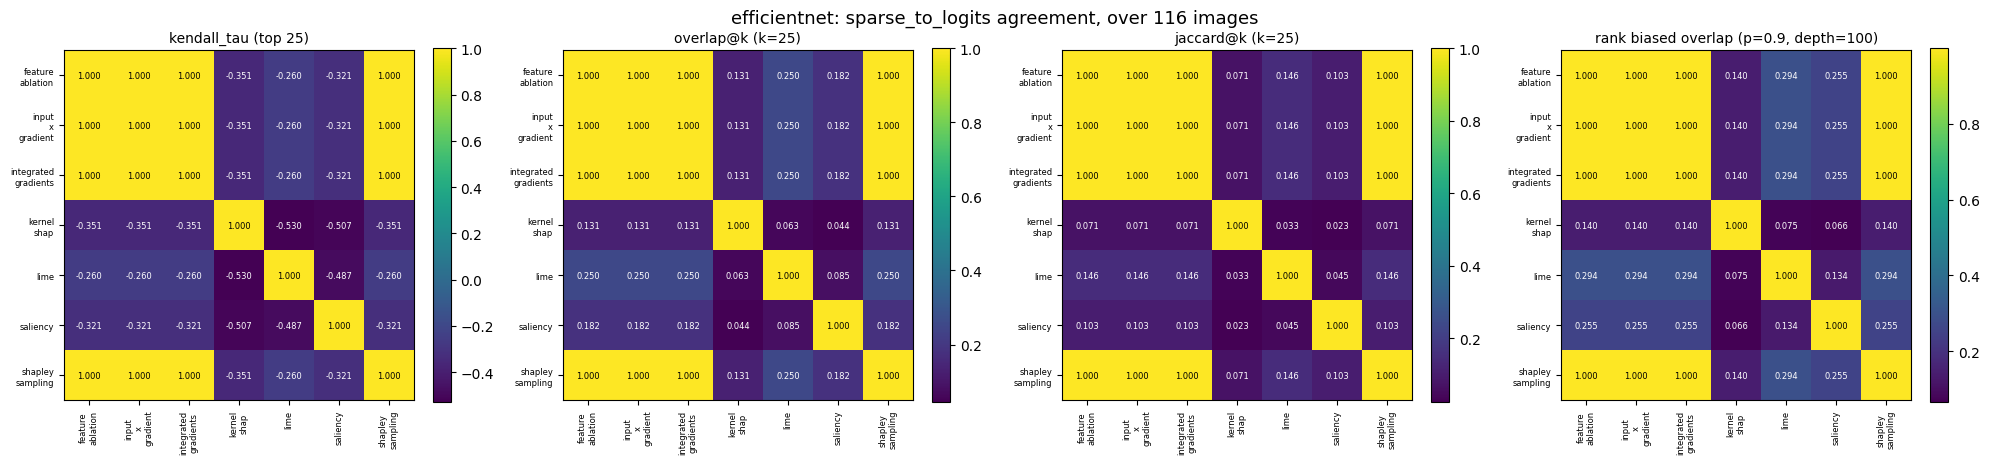

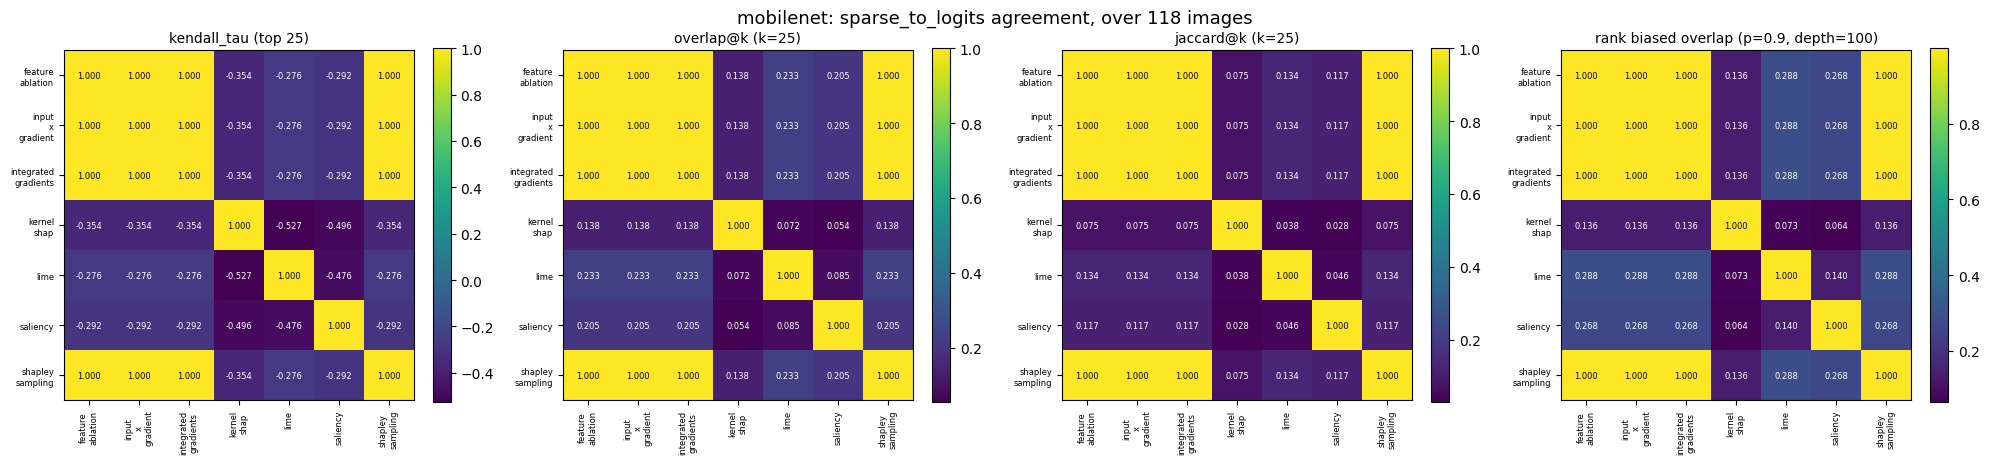

In [17]:
for model in RUNS:
    names, vectors = sparse_vectors(model, n_images=200)
    mats = agreement_matrices(names, vectors, DIM_TOP_K)
    fig = plot_matrices(names, mats, f"{model}: sparse_to_logits agreement, over {len(vectors)} images", DIM_TOP_K)
    fig.savefig(f"rq1_{model}_sparse.png", dpi=130, bbox_inches="tight")
    plt.show()

As the demo predicted, feature_ablation, input_x_gradient, integrated_gradients and
shapley_sampling agree perfectly (they are the same formula on a linear path).
Saliency, lime and kernel_shap measure importance differently and stand apart. So
for this analysis the agreement question has a known answer, which is a nice check
that the pipeline is correct, but not very informative.

### image_to_sparse agreement

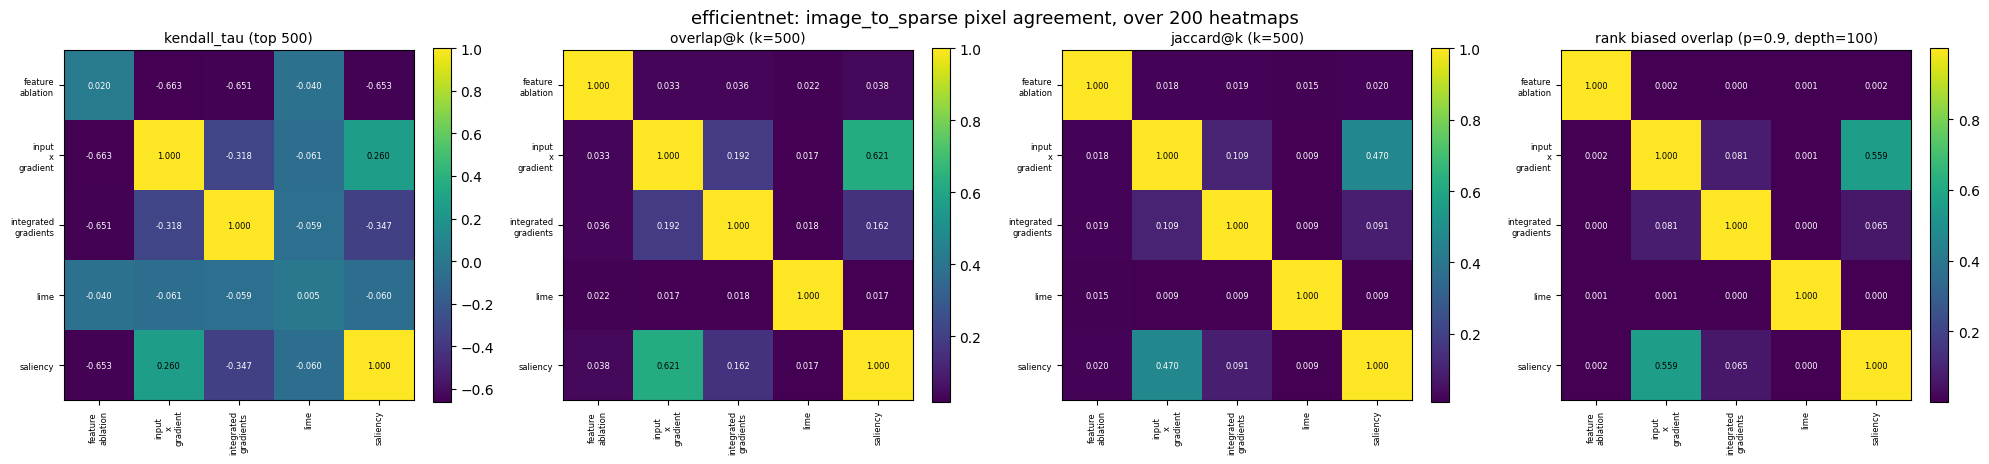

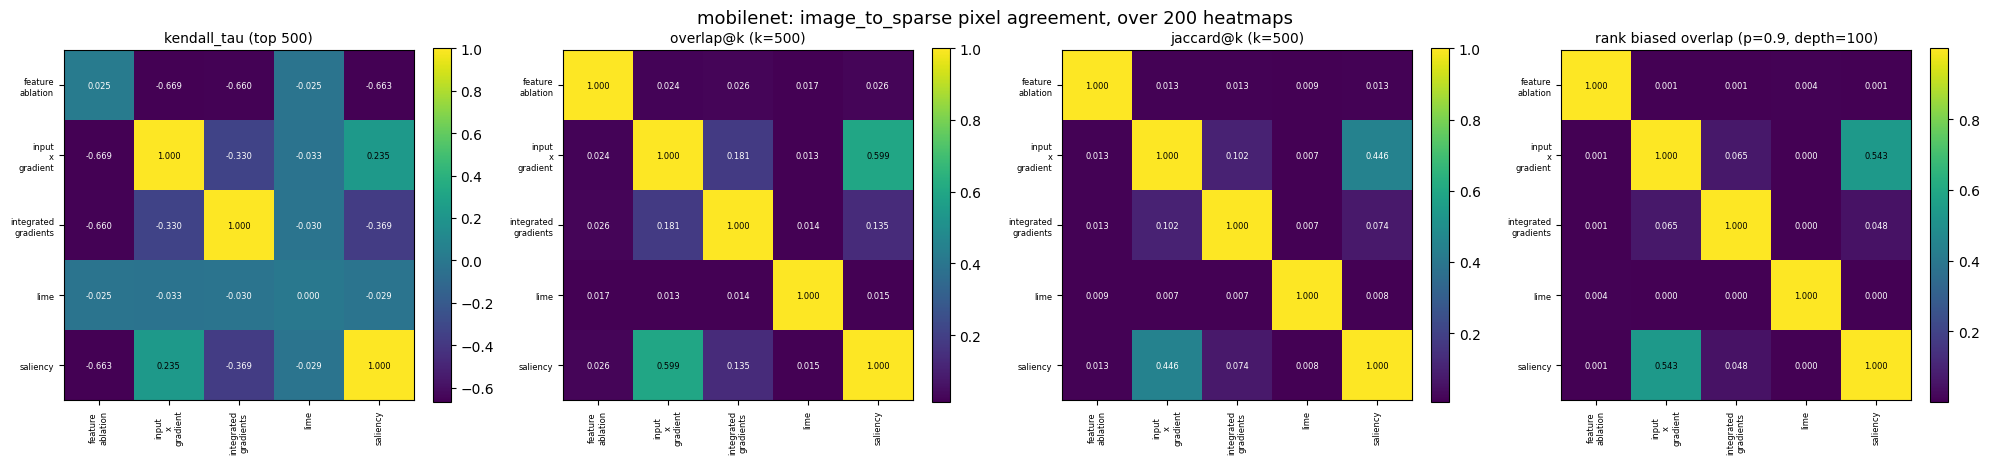

In [18]:
for model in RUNS:
    names, vectors = image_vectors(model, n_targets=200)
    mats = agreement_matrices(names, vectors, PIXEL_TOP_K)
    fig = plot_matrices(names, mats, f"{model}: image_to_sparse pixel agreement, over {len(vectors)} heatmaps", PIXEL_TOP_K)
    fig.savefig(f"rq1_{model}_image.png", dpi=130, bbox_inches="tight")
    plt.show()

Here the methods genuinely differ, because the pixels reach a sparse dimension
through the non-linear CNN. The clearest signal is that the two gradient methods,
input_x_gradient and saliency, agree most on which pixels matter, while lime is
almost orthogonal to everyone (its superpixel surrogate picks different regions).
This is the more interesting test of agreement.

One caveat on the kendall_tau panel here. kendall_tau compares every pair of items
and counts whether the two methods order them the same way; pairs that are tied
(equal score) are dropped. As the demo showed, the perturbation methods give the
same score to every pixel inside a superpixel, so most pixel pairs are ties and get
dropped, leaving kendall_tau to rank on a tiny noisy remainder. So trust overlap@k,
jaccard@k and rank biased overlap here, which only ask whether a pixel is in the
top-k set and so do not care about ties within a superpixel. Doing this properly at
the superpixel level (one score per superpixel) is a clean fix for later.